# Filter Atoms (Qwen / vLLM)

Clean up extracted atoms from chesspublishing using a second LLM pass via local vLLM.

Input: `data/chesspublishinga_included.jsonl` (Qwen3-extracted atoms)

Actions (in priority order):
1. **Keep** — Concrete, verifiable positional facts about the move
2. **Contextualize** — Not self-contained; rewrite with missing context so it stands alone
3. **Move to alternative** — About a different move, not the played one
4. **Remove** — Generic labels only (no positional content)

In [1]:
import asyncio
import json
import os
import random
import time

import chess
import chess.svg
import openai
from IPython.display import display, SVG, Markdown

DIR = os.path.dirname(os.path.abspath('__file__'))
INPUT_PATH = os.path.join(DIR, 'data', 'chesspublishinga_included.jsonl')

with open(INPUT_PATH) as f:
    all_rows = [json.loads(line) for line in f]

total_atoms = sum(len(r['extracted'].get('reasoning', [])) for r in all_rows)
n_alt = sum(1 for r in all_rows if r['extracted'].get('alternative'))
print(f'Loaded {len(all_rows)} positions from {INPUT_PATH}')
print(f'Total reasoning atoms: {total_atoms}')
print(f'Positions with alternatives: {n_alt}')

# vLLM async client
MODEL = 'Qwen/Qwen3-32B'
BASE_URL = 'http://127.0.0.1:8000/v1'
WORKERS = 32

client = openai.AsyncOpenAI(base_url=BASE_URL, api_key='not-needed')
print(f'Model: {MODEL} @ {BASE_URL}, workers: {WORKERS}')

Loaded 438 positions from /Users/ashwin/Documents/Princeton/chess/chess_annotation/evaluation/data/chesspublishing/data/chesspublishinga_included.jsonl
Total reasoning atoms: 612
Positions with alternatives: 106
Model: Qwen/Qwen3-32B @ http://127.0.0.1:8000/v1, workers: 32


In [2]:
def parse_json(text):
    """Parse JSON from LLM output, stripping markdown code fences if present."""
    text = text.strip()
    if text.startswith('```'):
        text = text.split('\n', 1)[1]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
    return json.loads(text)

---
# Prompt + few-shot demos

In [3]:
FILTER_PROMPT = """\
You are filtering extracted reasoning atoms from chess commentary.

You will receive the FULL extracted JSON for a position (FEN, move played,
original commentary, reasoning atoms, and any alternative move atoms).

Classify each atom as: keep / contextualize / move_to_alternative / remove.

These rules apply to BOTH reasoning atoms AND alternative atoms.

KEEP an atom if it states a concrete, verifiable positional fact about what
the move does: attacks, defends, controls, pins, blocks, develops, opens/
closes lines, creates threats, prevents opponent plans, explains why a move
is bad, etc.

CONTEXTUALIZE an atom that has useful content but is not self-contained on
its own. An atom is not self-contained if it references a consequence,
position, or piece without enough context to verify it independently.

Each atom stays SEPARATE — do NOT combine multiple atoms into one. Instead,
add the missing context so each atom is independently verifiable.
  Original: "On e4 the knight controls d6 and f6"
  Contextualized: "After Nd2, the knight on e4 would control d6 and f6."
Output: {"action": "contextualize", "new_text": "After Nd2, ..."}

When contextualizing, always anchor to the RELEVANT move as the subject:
  For reasoning atoms, anchor to the played move.
    Correct: "After 2.a3, White allows Black to control the center with ...d5."
    Wrong:   "After 2...d5, White allows Black to take control by playing d5."
  For alternative atoms, anchor to the alternative move.
    Correct: "After Na5, the knight heads to c4 to blockade the doubled pawn."

IMPORTANT: Only add REFERENTIAL context — which move, which piece, which
square, which position. Do NOT add new chess claims, analysis, or
consequences that were not in the original atom. The goal is to make the
existing claim self-contained, not to enrich it.

MOVE_TO_ALTERNATIVE (reasoning atoms only — not for alternative atoms):
If a reasoning atom describes an ALTERNATIVE move (a move NOT played) and
its consequences, move it to the alternatives.
  Output: {"action": "move_to_alternative", "move": "Bf4", "text": "..."}
  You may paraphrase the text so it reads naturally.

Conclusion vs. detailed analysis of alternatives:
- A CONCLUSION that the played move avoids or is better than an alternative
  is KEEP: "Qh4 avoids the inferior Qg5" -> KEEP.
- A DETAILED ANALYSIS of what happens after the alternative move is
  MOVE_TO_ALTERNATIVE: "After 32.Qc1 Nxd4 33.Bxd4 Rxd4, Black threatens
  Rd3" -> MOVE_TO_ALTERNATIVE for Qc1.
- When an atom MIXES both (conclusion + detailed line), SPLIT it using
  kept_brief:
  {"action": "move_to_alternative", "move": "Qc1",
   "text": "After 32.Qc1 Nxd4 33.Bxd4 Rxd4, Black threatens Rd3.",
   "kept_brief": "Qb2 avoids Qc1, which leads to dangerous threats on the d-file."}
  kept_brief stays in reasoning, text goes to the alternative.

REMOVE an atom if:
- It is a generic label with no concrete positional content.
  "Nbd2 is a typical Colle Attack manoeuvre." — naming an opening or
  saying "typical/standard" without any positional claim is not useful.
  "e6 is a solid alternative." — vague label, remove.
  "Na5 reroutes the knight to c4 to blockade the doubled pawn." — concrete, keep.
- It describes what a DIFFERENT move does and is clearly derived from
  parent context, not from the commentary about the current move. Compare
  the atom against the "annotation" field — if the claim appears only in
  "parent_comment" and not in "annotation", remove it.

--- OUTPUT FORMAT ---

Output ONLY valid JSON:
{"atoms": [
  {"index": 0, "text": "...", "action": "keep"},
  {"index": 1, "text": "...", "action": "contextualize", "new_text": "..."},
  {"index": 2, "text": "...", "action": "move_to_alternative", "move": "Qc1",
   "text": "detailed line...", "kept_brief": "brief conclusion..."},
  {"index": 3, "text": "...", "action": "remove", "reason": "generic label"}
 ],
 "alt_atoms": [
  {"alt_move": "Na5", "index": 0, "text": "...", "action": "keep"},
  {"alt_move": "Na5", "index": 1, "text": "...", "action": "remove", "reason": "vague label"}
 ]
}

Omit "alt_atoms" when the position has no alternatives.

Be conservative: when in doubt, KEEP. Prefer CONTEXTUALIZE over REMOVE when
an atom has useful content but just lacks context. Prefer MOVE_TO_ALTERNATIVE
over REMOVE when the atom is about a different move.
"""

print(f'Filter prompt: {len(FILTER_PROMPT)} chars')

Filter prompt: 4346 chars


In [4]:
# --- Few-shot demos ---
#
# Demo 1: keep + remove (vague atom removed)
# Demo 2: keep + contextualize (add referential context)
# Demo 3: keep + move_to_alternative (atoms about Black's responses)
# Demo 4: alternatives filtered (vague alt removed, concrete alt kept)

DEMO_DATA = [
    # Demo 1: Rab8 — 2 keep, 1 remove
    {
        'context': {
            'fen': 'r4rk1/pppq1ppp/2nb1n2/4p3/2Q3b1/2NP1NP1/PP2PPBP/R1BR2K1 b - - 6 10',
            'move_uci': 'a8b8',
            'move_san': 'Rab8',
            'annotation': "By defending b7 Black frees his c6-knight to play ...Nd4, and prepares a tactical trick.",
            'is_mainline': True,
            'parent_comment': '',
            'reasoning': [
                'Rab8 defends the b7-pawn.',
                'By defending b7, Rab8 frees the knight on c6 to move to d4.',
                'Rab8 also prepares a tactical trick.',
            ],
        },
        'response': {
            'atoms': [
                {'index': 0, 'text': 'Rab8 defends the b7-pawn.', 'action': 'keep'},
                {'index': 1, 'text': 'By defending b7, Rab8 frees the knight on c6 to move to d4.', 'action': 'keep'},
                {'index': 2, 'text': 'Rab8 also prepares a tactical trick.', 'action': 'remove',
                 'reason': 'vague — no concrete positional content about the tactic'},
            ]
        },
    },
    # Demo 2: Nh4 — 2 keep, 1 contextualize
    {
        'context': {
            'fen': 'r2r2k1/1bq1bppp/p7/nppn4/4N3/4PNP1/PB2QPBP/2RR2K1 w - - 0 18',
            'move_uci': 'f3h4',
            'move_san': 'Nh4',
            'annotation': "Trying to go to f5 and force Black to open the long diagonal for White's bishop, but there are no real threats on the diagonal, so Nh4 is not so effective.",
            'is_mainline': True,
            'parent_comment': '',
            'reasoning': [
                'Nh4 intends to reroute the knight to f5.',
                "The idea of Nh4 is to induce Black to open the long diagonal for White's bishop.",
                'There are no real threats on the long diagonal, so this plan is not effective.',
            ],
        },
        'response': {
            'atoms': [
                {'index': 0, 'text': 'Nh4 intends to reroute the knight to f5.', 'action': 'keep'},
                {'index': 1, 'text': "The idea of Nh4 is to induce Black to open the long diagonal for White's bishop.", 'action': 'keep'},
                {'index': 2, 'text': 'There are no real threats on the long diagonal, so this plan is not effective.',
                 'action': 'contextualize',
                 'new_text': "After Nh4, there are no real threats on the long diagonal for White's bishop, so this plan is not effective."},
            ]
        },
    },
    # Demo 3: Bxf6 — 1 keep, 2 move_to_alternative
    {
        'context': {
            'fen': 'rr5k/2pqB1pp/2p2p2/1n2p3/p7/P2P2P1/1R1NPPbP/1QR3K1 w - - 0 25',
            'move_uci': 'e7f6',
            'move_san': 'Bxf6',
            'annotation': "25. Bxf6 and now: 25... gxf6 26. Kxg2 (and White is slightly better due to his superior structure); or 25... Bh3 26. Bxe5 Qd5 27. Nf3 Rf8 28. Rxb5 cxb5 29. Rxc7 Rxf3 30. Bxg7+ Kg8 31. exf3 (and White wins)",
            'is_mainline': False,
            'parent_comment': '',
            'reasoning': [
                'Bxf6 forces Black to choose between recapturing with gxf6 and accepting an inferior pawn structure, or playing Bh3 and allowing White to win by tactical means.',
                'After gxf6, White can play Kxg2 and stand slightly better because of the superior pawn structure.',
                'After Bh3, White has the tactical sequence Bxe5, Nf3, Rxb5, and Rxc7, after which White wins.',
            ],
        },
        'response': {
            'atoms': [
                {'index': 0, 'text': 'Bxf6 forces Black to choose between recapturing with gxf6 and accepting an inferior pawn structure, or playing Bh3 and allowing White to win by tactical means.',
                 'action': 'keep'},
                {'index': 1, 'text': 'After gxf6, White can play Kxg2 and stand slightly better because of the superior pawn structure.',
                 'action': 'move_to_alternative', 'move': 'gxf6'},
                {'index': 2, 'text': 'After Bh3, White has the tactical sequence Bxe5, Nf3, Rxb5, and Rxc7, after which White wins.',
                 'action': 'move_to_alternative', 'move': 'Bh3'},
            ]
        },
    },
    # Demo 4: O-O with alternatives — vague alt removed, concrete alt kept
    {
        'context': {
            'fen': 'r2qk2r/p1p1npp1/1pn1b2p/3pP3/3P1B2/2PB1N2/P1PQ2PP/1R3RK1 b kq - 1 12',
            'move_uci': 'e8g8',
            'move_san': 'O-O',
            'annotation': "Walking right into the teeth of the storm! Black might have tried Na5, with the object of swinging the knight to c4 where it blockades the doubled pawn and interferes with White's pieces.",
            'is_mainline': True,
            'parent_comment': '',
            'reasoning': [
                "O-O castles into White's prepared kingside attack.",
                "Black misses the opportunity to exploit White's doubled c-pawns.",
            ],
            'alternatives': [
                {'move': 'Na5', 'reasoning': [
                    'Na5 reroutes the knight toward c4 to blockade the doubled c-pawn.',
                    "A knight on c4 would interfere with the coordination of White's pieces.",
                ]},
                {'move': 'Bd6', 'reasoning': [
                    'Bd6 is a solid alternative.',
                ]},
            ],
        },
        'response': {
            'atoms': [
                {'index': 0, 'text': "O-O castles into White's prepared kingside attack.", 'action': 'keep'},
                {'index': 1, 'text': "Black misses the opportunity to exploit White's doubled c-pawns.", 'action': 'keep'},
            ],
            'alt_atoms': [
                {'alt_move': 'Na5', 'index': 0, 'text': 'Na5 reroutes the knight toward c4 to blockade the doubled c-pawn.', 'action': 'keep'},
                {'alt_move': 'Na5', 'index': 1, 'text': "A knight on c4 would interfere with the coordination of White's pieces.", 'action': 'keep'},
                {'alt_move': 'Bd6', 'index': 0, 'text': 'Bd6 is a solid alternative.', 'action': 'remove', 'reason': 'vague label — no concrete positional content'},
            ],
        },
    },
]


def build_user_prompt(context):
    """Build the user message from position context dict."""
    reasoning = context['reasoning']
    atoms_text = '\n'.join(f'{i}. "{a}"' for i, a in enumerate(reasoning))

    prompt = (
        f'Position data:\n```json\n{json.dumps(context, indent=2)}\n```\n\n'
        f'Reasoning atoms to classify:\n{atoms_text}'
    )

    # Include alternative atoms if present
    alts = context.get('alternatives', [])
    if alts:
        alt_lines = []
        for alt in alts:
            move = alt.get('move', '?')
            for i, a in enumerate(alt.get('reasoning', [])):
                alt_lines.append(f'[{move}] {i}. "{a}"')
        if alt_lines:
            prompt += '\n\nAlternative atoms to classify:\n' + '\n'.join(alt_lines)

    return prompt


def build_demo_messages():
    """Build few-shot (user, assistant) pairs from DEMO_DATA."""
    msgs = []
    for demo in DEMO_DATA:
        msgs.append({'role': 'user', 'content': build_user_prompt(demo['context'])})
        msgs.append({'role': 'assistant', 'content': json.dumps(demo['response'])})
    return msgs


DEMO_MESSAGES = build_demo_messages()
print(f'{len(DEMO_DATA)} demos, {len(DEMO_MESSAGES)} messages')
print(f'Demo message total chars: {sum(len(m["content"]) for m in DEMO_MESSAGES)}')

4 demos, 8 messages
Demo message total chars: 6010


---
# Filter functions

In [5]:
async def filter_atoms(row, semaphore=None):
    """Classify each reasoning and alternative atom."""
    extracted = row['extracted']
    reasoning = extracted.get('reasoning', [])

    # Gather existing alternatives
    existing_alt = extracted.get('alternative')
    alt_list = []
    if existing_alt:
        alt_list = existing_alt if isinstance(existing_alt, list) else [existing_alt]

    if not reasoning and not alt_list:
        return {'atoms': [], 'alt_atoms': [],
                'filtered_reasoning': [], 'filtered_alternatives': []}

    # Full context for the LLM
    context = {
        'fen': row['fen'],
        'move_uci': row['move_uci'],
        'move_san': row.get('move_san', ''),
        'annotation': row['annotation'],
        'is_mainline': row.get('is_mainline', True),
        'parent_comment': row.get('parent_comment', ''),
        'reasoning': reasoning,
    }
    if extracted.get('variation'):
        context['variation'] = extracted['variation']
    if alt_list:
        context['alternatives'] = [
            {'move': a.get('move', '?'), 'reasoning': a.get('reasoning', [])}
            for a in alt_list
        ]

    user_msg = build_user_prompt(context)

    messages = [{'role': 'system', 'content': FILTER_PROMPT}]
    messages.extend(DEMO_MESSAGES)
    messages.append({'role': 'user', 'content': user_msg})

    async def _call():
        resp = await client.chat.completions.create(
            model=MODEL,
            messages=messages,
            temperature=0,
            max_completion_tokens=2048,
            extra_body={'chat_template_kwargs': {'enable_thinking': False}},
        )
        return resp.choices[0].message.content.strip()

    if semaphore:
        async with semaphore:
            text = await _call()
    else:
        text = await _call()

    try:
        result = parse_json(text)
    except json.JSONDecodeError:
        return {'atoms': [], 'alt_atoms': [], 'error': 'JSON parse error', 'raw': text,
                'filtered_reasoning': reasoning,
                'filtered_alternatives': alt_list}

    if 'atoms' not in result:
        return {'atoms': [], 'alt_atoms': [], 'error': 'no atoms key',
                'filtered_reasoning': reasoning,
                'filtered_alternatives': alt_list}

    # --- Process reasoning atoms ---
    atoms_by_idx = {a['index']: a for a in result['atoms']}
    new_alts_from_reasoning = []
    filtered_reasoning = []

    for i, atom_text in enumerate(reasoning):
        a = atoms_by_idx.get(i, {})
        action = a.get('action', 'keep')

        if action == 'remove':
            continue
        if action == 'move_to_alternative':
            new_alts_from_reasoning.append({
                'move': a.get('move', '?'),
                'text': a.get('text', atom_text),
            })
            if a.get('kept_brief'):
                filtered_reasoning.append(a['kept_brief'])
            continue
        if action == 'contextualize' and a.get('new_text'):
            filtered_reasoning.append(a['new_text'])
        else:
            filtered_reasoning.append(atom_text)

    # --- Process alternative atoms ---
    raw_alt_atoms = result.get('alt_atoms', [])
    # Index alt_atoms by (alt_move, index)
    alt_atoms_lookup = {}
    for aa in raw_alt_atoms:
        key = (aa.get('alt_move', '?'), aa.get('index', 0))
        alt_atoms_lookup[key] = aa

    filtered_alternatives = []
    for alt in alt_list:
        move = alt.get('move', '?')
        old_reasoning = alt.get('reasoning', [])
        new_reasoning = []
        for i, atom_text in enumerate(old_reasoning):
            aa = alt_atoms_lookup.get((move, i), {})
            action = aa.get('action', 'keep')
            if action == 'remove':
                continue
            if action == 'contextualize' and aa.get('new_text'):
                new_reasoning.append(aa['new_text'])
            else:
                new_reasoning.append(atom_text)
        if new_reasoning:
            filtered_alternatives.append({'move': move, 'reasoning': new_reasoning})

    return {
        'atoms': result['atoms'],
        'alt_atoms': raw_alt_atoms,
        'filtered_reasoning': filtered_reasoning,
        'new_alts_from_reasoning': new_alts_from_reasoning,
        'filtered_alternatives': filtered_alternatives,
    }


def build_output_row(row, result):
    """Build output row from input row + filter result."""
    out_row = dict(row)
    filtered_extracted = dict(row['extracted'])
    filtered_extracted['reasoning'] = result['filtered_reasoning']

    # Merge: filtered existing alternatives + new alternatives from reasoning atoms
    alt_by_move = {}

    # First: filtered existing alternatives
    for fa in result.get('filtered_alternatives', []):
        m = fa['move']
        alt_by_move[m] = fa

    # Then: new alternatives moved from reasoning
    for a in result.get('new_alts_from_reasoning', []):
        move = a['move']
        if move not in alt_by_move:
            alt_by_move[move] = {'move': move, 'reasoning': []}
        alt_by_move[move]['reasoning'].append(a['text'])

    if alt_by_move:
        alt_list = list(alt_by_move.values())
        filtered_extracted['alternative'] = alt_list[0] if len(alt_list) == 1 else alt_list
    else:
        filtered_extracted.pop('alternative', None)

    out_row['extracted'] = filtered_extracted
    out_row['filter_result'] = result.get('atoms', [])
    out_row['filter_alt_result'] = result.get('alt_atoms', [])
    return out_row


print('filter_atoms, build_output_row ready')

filter_atoms, build_output_row ready


---
# Sample run: 20 positions

In [6]:
SEED = 45
N_SAMPLE = 20

rng = random.Random(SEED)
review_order = list(range(len(all_rows)))
rng.shuffle(review_order)

sample_rows = [all_rows[i] for i in review_order[:N_SAMPLE]]

sample_results = []
sem = asyncio.Semaphore(WORKERS)

for i, row in enumerate(sample_rows):
    san = row.get('move_san', '?')
    print(f'[{i+1}/{N_SAMPLE}] {row["game"]} \u2014 {san}')
    result = await filter_atoms(row, semaphore=sem)
    out_row = build_output_row(row, result)
    sample_results.append((row, result, out_row))

print(f'\nDone. {N_SAMPLE} positions filtered.')

[1/20] Honos, Attila vs Kantor, Gergely — a3
[2/20] Genocchio, Daniele vs Altini, Nicola — fxe6
[3/20] Karpatchev, Aleksandr vs Mazur, Stefan — Kd8
[4/20] Karpatchev, Aleksandr vs Mazur, Stefan — Qd8
[5/20] Azmaiparashvili, Zurab vs Mahjoob, Morteza — a4
[6/20] Karpatchev, Aleksandr vs Mazur, Stefan — h6
[7/20] Genocchio, Daniele vs Altini, Nicola — Ne8
[8/20] Honos, Attila vs Kantor, Gergely — Nf4
[9/20] Genocchio, Daniele vs Altini, Nicola — Rf1
[10/20] Short, Nigel D vs Caruana, Fabiano — O-O
[11/20] Pridorozhni, Aleksei vs Jakovenko, Dmitrij — Rd8
[12/20] Short, Nigel D vs Caruana, Fabiano — Qd2
[13/20] Sevian, Samuel vs Grandelius, Nils — d4
[14/20] Azmaiparashvili, Zurab vs Mahjoob, Morteza — Nxb5
[15/20] Arwanitakis, Michael vs Woeber, Friedrich — Bd2
[16/20] Karpatchev, Aleksandr vs Mazur, Stefan — Nc6
[17/20] Arwanitakis, Michael vs Woeber, Friedrich — Qxa2
[18/20] Miralles, Gilles vs Bologan, Viktor — Bh3
[19/20] Sitnikov, Anton vs Aveskulov, Valeriy — Bxf4
[20/20] Ardaman, M

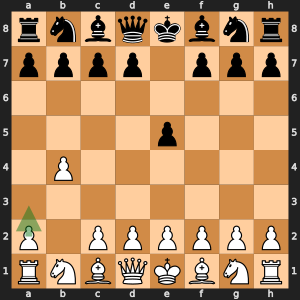

### [1/20] Honos, Attila vs Kantor, Gergely — White plays a3 (variation)

> 2. a3 cedes the centre without a fight, for example: 2... d5 3. Bb2 Bd6 4. Nf3 Qe7 5. e3 Nf6 6. d4 e4 7. Nfd2 c6 8. c4

*Context: Black's most principled reply, simply taking aim at the b4-pawn. Other moves are perfectly playable of course, for example:*

#### Original extraction
1. a3 cedes the center without a fight.
2. After 2...d5, White allows Black to take control of the center.

*Variation*: `2... d5 3. Bb2 Bd6 4. Nf3 Qe7 5. e3 Nf6 6. d4 e4 7. Nfd2 c6 8. c4`

#### Reasoning filter decisions
✅ a3 cedes the center without a fight.

🔄 After 2...d5, White allows Black to take control of the center.

  → **After 2...d5, White allows Black to take control of the center by playing d5.**

#### Result
1. a3 cedes the center without a fight.
2. After 2...d5, White allows Black to take control of the center by playing d5.

**2 → 2 reasoning atoms (1 contextualized)**

---

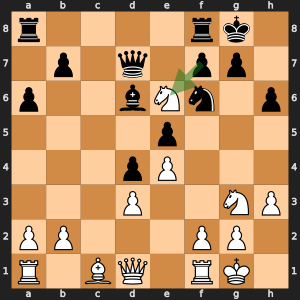

### [2/20] Genocchio, Daniele vs Altini, Nicola — Black plays fxe6 (mainline)

> Accepting doubled pawns, but better to do so than allow the white knight into f5.

*Context: And this prevents any notion of ...Ng4 in the event of f2-f4.*

#### Original extraction
1. fxe6 accepts doubled pawns.
2. fxe6 prevents the white knight from advancing to f5.

#### Reasoning filter decisions
✅ fxe6 accepts doubled pawns.

✅ fxe6 prevents the white knight from advancing to f5.

#### Result
1. fxe6 accepts doubled pawns.
2. fxe6 prevents the white knight from advancing to f5.

**2 → 2 reasoning atoms**

---

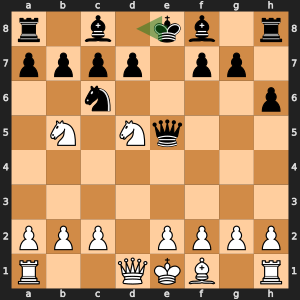

### [3/20] Karpatchev, Aleksandr vs Mazur, Stefan — Black plays Kd8 (variation)

> 8...Kd8 was played in Matjushin,G (2372)-Melnikov,D (2276) St Petersburg 2001 0-1 (40) and here most accurate is: 9. Nbxc7 Qxb2 10. c3 (and Black is much worse due to his king being stuck in the centre)

*Context: As we have seen in several of the earlier notes, Black is caught out by the weakness of the c7-pawn.*

#### Original extraction
1. Kd8 centralizes the king.

*Variation*: `9. Nbxc7 Qxb2 10. c3`

#### Reasoning filter decisions
✅ Kd8 centralizes the king.

#### Result
1. Kd8 centralizes the king.

**1 → 1 reasoning atoms**

---

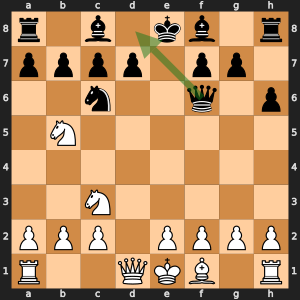

### [4/20] Karpatchev, Aleksandr vs Mazur, Stefan — Black plays Qd8 (mainline)

> The alternatives are no more promising: 8. Nd5 Bb4+ 9. Nxb4 (This works out well for White, but he has an even better option here with:) Nxb4 10. Qd2 Na6 (Instead:) 11. Nxa7 (Winning a pawn through a cute tactic. Alternatively:) O-O (Instead:) 12. Nxc8 Qf6 13. e3 Rfxc8

*Context: As we have seen in several of the earlier notes, Black is caught out by the weakness of the c7-pawn.*

#### Original extraction
1. Qd8 is a retreat that avoids immediate confrontation with White's knight on b5.

*Alternative* **Bc5**: 
  - Bc5 is an alternative to Qd8.

#### Reasoning filter decisions
✅ Qd8 is a retreat that avoids immediate confrontation with White's knight on b5.

#### Alternative filter decisions
❌ [Bc5] Bc5 is an alternative to Qd8. — *vague label — no concrete positional content*

#### Result
1. Qd8 is a retreat that avoids immediate confrontation with White's knight on b5.

**1 → 1 reasoning atoms (1 alt removed)**

---

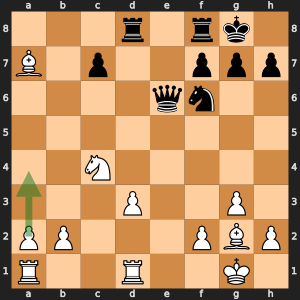

### [5/20] Azmaiparashvili, Zurab vs Mahjoob, Morteza — White plays a4 (mainline)

> White's plan is clear - he will push the a-pawn supported by the bishops. Black's problem is deciding quite how to stop it!

*Context: White prefers to keep this important piece,*

#### Original extraction
1. a4 supports White's plan to push the a-pawn, which is supported by the bishops.

#### Reasoning filter decisions
🔄 a4 supports White's plan to push the a-pawn, which is supported by the bishops.

  → **After a4, White supports the plan to push the a-pawn, which is supported by the bishops.**

#### Result
1. After a4, White supports the plan to push the a-pawn, which is supported by the bishops.

**1 → 1 reasoning atoms (1 contextualized)**

---

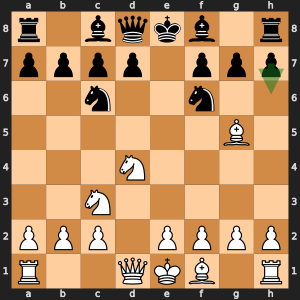

### [6/20] Karpatchev, Aleksandr vs Mazur, Stefan — Black plays h6 (mainline)

> A natural move, putting the question to the g5-bishop, but Black doesn't have time for this. Instead: 6. Bxf6 Qxf6 7. Ndb5 (As we have seen in several of the earlier notes, Black is caught out by the weakness of the c7-pawn.) Qd8 (The alternatives are no more promising:) 8. Nd5 Bb4+ 9. Nxb4 (This works out well for White, but he has an even better option here with:) Nxb4 10. Qd2 Na6 (Instead:) 11. Nxa7 (Winning a pawn through a cute tactic. Alternatively:) O-O (Instead:)

*Context: Black has also played:*

#### Original extraction
1. h6 puts the question to the g5-bishop.
2. Black doesn't have time for this move.

*Alternative* **Be7**: 
  - 5...Be7 is even worse, since after Nf5, Black is already struggling to defend the g7-pawn.

*Alternative* **Bb4**: 
  - 5...Bb4 is a reliable reply.

*Variation*: `6. Bxf6 Qxf6 7. Ndb5 Qd8 8. Nd5 Bb4+ 9. Nxb4 Nxb4 10. Qd2 Na6 11. Nxa7`

#### Reasoning filter decisions
✅ h6 puts the question to the g5-bishop.

🔄 Black doesn't have time for this move.

  → **After h6, Black doesn't have time to challenge the g5-bishop.**

#### Alternative filter decisions
✅ [Be7] 5...Be7 is even worse, since after Nf5, Black is already struggling to defend the g7-pawn.

❌ [Bb4] 5...Bb4 is a reliable reply. — *vague label — no concrete positional content*

#### Result
1. h6 puts the question to the g5-bishop.
2. After h6, Black doesn't have time to challenge the g5-bishop.

*Alternative* **Be7**:
  - 5...Be7 is even worse, since after Nf5, Black is already struggling to defend the g7-pawn.

**2 → 2 reasoning atoms (1 contextualized, 1 alt removed)**

---

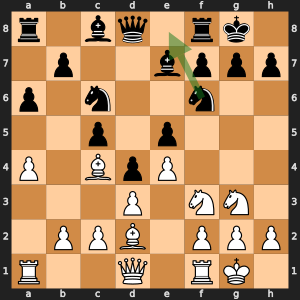

### [7/20] Genocchio, Daniele vs Altini, Nicola — Black plays Ne8 (variation)

> 10...Ne8 of Demidov-Davydov, Kazan 2014, which continued instructively: 11. a5 Bg4 12. h3 Bxf3 13. Qxf3 Bg5 14. Be1 g6 15. Ne2 Ng7 16. g3 Kh8; or 11. c3 (is an attempt to cut across Black's ...Nd6 plan and now, for instance,) Nc7 12. cxd4 cxd4 13. b4 (gives White a pull)

*Context: . Yes, Black has pushed plenty of pawns, but in this reversed Tango it's not so easy for White to punish him. Quite a natural continuation was the*

#### Original extraction
1. Ne8 prepares for the ...Nd6 plan.

*Variation*: `11. a5 Bg4 12. h3 Bxf3 13. Qxf3 Bg5 14. Be1 g6 15. Ne2 Ng7 16. g3 Kh8; or 11. c3 Nc7 12. cxd4 cxd4 13. b4`

#### Reasoning filter decisions
✅ Ne8 prepares for the ...Nd6 plan.

#### Result
1. Ne8 prepares for the ...Nd6 plan.

**1 → 1 reasoning atoms**

---

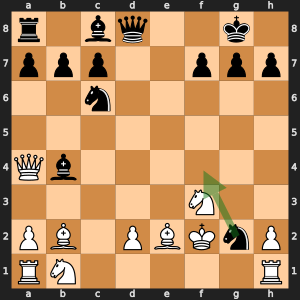

### [8/20] Honos, Attila vs Kantor, Gergely — Black plays Nf4 (variation)

> 12...Nf4 and Black won quickly after: 13. Nc3 Bg4 14. Raf1 Bxf3 15. Bxf3 Nd3+ 16. Kg3 Qg5+ 17. Bg4 h5 (0-1 (17) Shershakov,D (2242)-Moroz,R (2403) Golubitskaya 2017)

*Context: when White has played:*

#### Original extraction
1. Nf4 threatens to attack the knight on e2.

*Variation*: `13. Nc3 Bg4 14. Raf1 Bxf3 15. Bxf3 Nd3+ 16. Kg3 Qg5+ 17. Bg4 h5`

#### Reasoning filter decisions
✅ Nf4 threatens to attack the knight on e2.

#### Result
1. Nf4 threatens to attack the knight on e2.

**1 → 1 reasoning atoms**

---

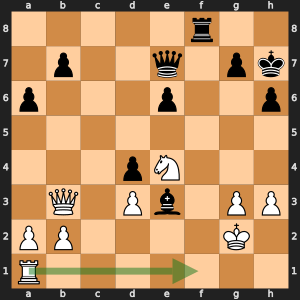

### [9/20] Genocchio, Daniele vs Altini, Nicola — White plays Rf1 (mainline)

> Confident defence from Genocchio, relying on the legendary power of queen and knight to hold the draw. Moreover, the Trojan knight on e4 does rather neutralise the bishop's advanced location.

*Context: The problem. White has blundered a pawn.*

#### Original extraction
1. Rf1 supports the queen on b3 and helps defend the position.
2. Rf1 relies on the combined power of the queen and knight to hold the draw.
3. The knight on e4 neutralises the bishop's advanced location.

#### Reasoning filter decisions
✅ Rf1 supports the queen on b3 and helps defend the position.

❌ Rf1 relies on the combined power of the queen and knight to hold the draw. — *vague label — no concrete positional content*

✅ The knight on e4 neutralises the bishop's advanced location.

#### Result
1. Rf1 supports the queen on b3 and helps defend the position.
2. The knight on e4 neutralises the bishop's advanced location.

**3 → 2 reasoning atoms (1 removed)**

---

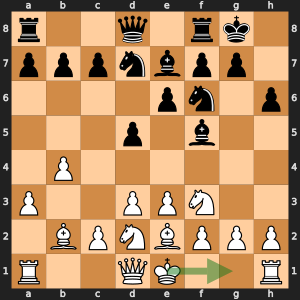

### [10/20] Short, Nigel D vs Caruana, Fabiano — White plays O-O (variation)

> 9. O-O would be normal, and after: 9... a5 10. Qb1 c6 11. c4 (the position is about equal)

*Context: Finally White brings the knight into the game.*

#### Original extraction
1. O-O brings the knight into the game.

*Alternative* **h3**: 
  - h3 is the beginning of a flawed plan.
  - White has not sufficient resources to start an attack against Black's king.
  - White will be severely punished for this.

*Variation*: `9... a5 10. Qb1 c6 11. c4`

#### Reasoning filter decisions
✅ O-O brings the knight into the game.

#### Alternative filter decisions
❌ [h3] h3 is the beginning of a flawed plan. — *vague label — no concrete positional content*

✅ [h3] White has not sufficient resources to start an attack against Black's king.

❌ [h3] White will be severely punished for this. — *vague consequence — no concrete positional content*

#### Result
1. O-O brings the knight into the game.

*Alternative* **h3**:
  - White has not sufficient resources to start an attack against Black's king.

**1 → 1 reasoning atoms (2 alt removed)**

---

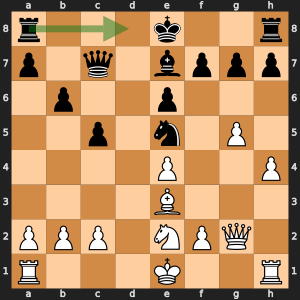

### [11/20] Pridorozhni, Aleksei vs Jakovenko, Dmitrij — Black plays Rd8 (variation)

> 14...Rd8 and White's king stays in the middle, since: 15. O-O (is not good because of) Nc4 (with a good position for Black)

*Context: White allows some unnecessary exchanges. With the advanced pawns it would be better to keep the queens on to have some attacking chances.*

#### Original extraction
1. Rd8 prepares Nc4, which attacks White's king position.

*Variation*: `15. O-O Nc4`

#### Reasoning filter decisions
🔄 Rd8 prepares Nc4, which attacks White's king position.

  → **After 14...Rd8, the knight can play Nc4, attacking White's king position.**

#### Result
1. After 14...Rd8, the knight can play Nc4, attacking White's king position.

**1 → 1 reasoning atoms (1 contextualized)**

---

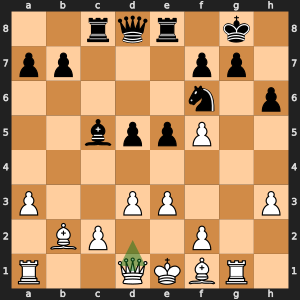

### [12/20] Short, Nigel D vs Caruana, Fabiano — White plays Qd2 (mainline)

> Since the queen can't go to the kingside, it tries to stay there, defending the pawns

*Context: This move can't really work, but it's already hard to suggest anything decent for White.*

#### Original extraction
1. Qd2 defends the pawns on the queenside.

*Alternative* **Qf3**: 
  - Qf3 would be the plan, but it is not possible because of 19... Qb6 20. Qg2 Bf8 (and both the bishop and the c2-pawn are hanging).

#### Reasoning filter decisions
✅ Qd2 defends the pawns on the queenside.

#### Alternative filter decisions
🔄 [Qf3] Qf3 would be the plan, but it is not possible because of 19... Qb6 20. Qg2 Bf8 (and both the bishop and the c2-pawn are hanging).

  → **After 19.Qf3, it is not possible because of 19... Qb6 20. Qg2 Bf8 (and both the bishop and the c2-pawn are hanging).**

#### Result
1. Qd2 defends the pawns on the queenside.

*Alternative* **Qf3**:
  - After 19.Qf3, it is not possible because of 19... Qb6 20. Qg2 Bf8 (and both the bishop and the c2-pawn are hanging).

**1 → 1 reasoning atoms (1 alt contextualized)**

---

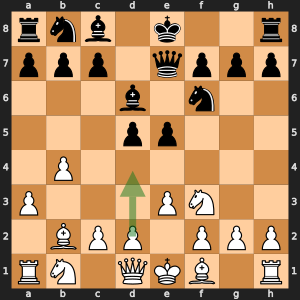

### [13/20] Sevian, Samuel vs Grandelius, Nils — White plays d4 (mainline)

> Clarifying the central pawn structure. Most games have instead continued with

*Context: Bolstering the b4-pawn like this is less popular than quick development with*

#### Original extraction
1. d4 clarifies the central pawn structure.

*Alternative* **c4**: 
  - Most games have instead continued with c4.

*Variation*: `6... c6 7. Nc3 d4 8. Ne2 dxe3 9. dxe3 O-O 10. Ng3 c5 11. b5 Rd8 12. Qc2`

#### Reasoning filter decisions
✅ d4 clarifies the central pawn structure.

#### Alternative filter decisions
❌ [c4] Most games have instead continued with c4. — *generic label — no concrete positional content*

#### Result
1. d4 clarifies the central pawn structure.

**1 → 1 reasoning atoms (1 alt removed)**

---

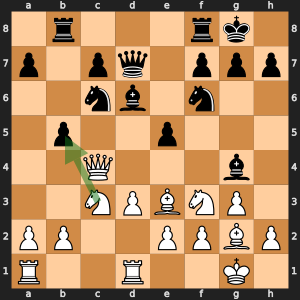

### [14/20] Azmaiparashvili, Zurab vs Mahjoob, Morteza — White plays Nxb5 (mainline)

> Incredible, White sacs his queen for two pieces.

*Context: White must take further control over d4 to stop the knight landing there.*

#### Original extraction
1. Nxb5 sacrifices the queen for two pieces.

#### Reasoning filter decisions
✅ Nxb5 sacrifices the queen for two pieces.

#### Result
1. Nxb5 sacrifices the queen for two pieces.

**1 → 1 reasoning atoms**

---

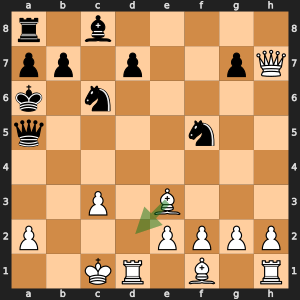

### [15/20] Arwanitakis, Michael vs Woeber, Friedrich — White plays Bd2 (mainline)

> Both defending c3 and threatening e4+.

*Context: Menacing ...Qxc3+ again with a perp.*

#### Original extraction
1. Bd2 defends the square c3.
2. Bd2 threatens e4+.

#### Reasoning filter decisions
✅ Bd2 defends the square c3.

🔄 Bd2 threatens e4+.

  → **After Bd2, White threatens e4+.**

#### Result
1. Bd2 defends the square c3.
2. After Bd2, White threatens e4+.

**2 → 2 reasoning atoms (1 contextualized)**

---

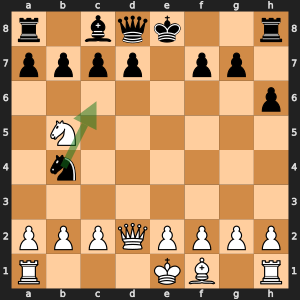

### [16/20] Karpatchev, Aleksandr vs Mazur, Stefan — Black plays Nc6 (variation)

> 10...Nc6 allows Black's king to be displaced: 11. Qe3+ Kf8 (Jung,H (2225)-Plotkin,V (2337) Kitchener 2009 1-0 (60), and here) 12. O-O-O (gives White a clear edge in development)

*Context: This works out well for White, but he has an even better option here with:*

#### Original extraction
1. 10...Nc6 allows White to displace Black's king with Qe3+.
2. After 11. Qe3+ Kf8, White can play 12. O-O-O to gain a clear edge in development.

*Alternative* **Na6**: 
  - Na6 is an even better option for Black.

*Variation*: `11. Qe3+ Kf8 12. O-O-O`

#### Reasoning filter decisions
✅ 10...Nc6 allows White to displace Black's king with Qe3+.

🔄 After 11. Qe3+ Kf8, White can play 12. O-O-O to gain a clear edge in development.

  → **After 11. Qe3+ Kf8, White can play 12. O-O-O, giving White a clear edge in development.**

#### Alternative filter decisions
❌ [Na6] Na6 is an even better option for Black. — *vague label — no concrete positional content*

#### Result
1. 10...Nc6 allows White to displace Black's king with Qe3+.
2. After 11. Qe3+ Kf8, White can play 12. O-O-O, giving White a clear edge in development.

**2 → 2 reasoning atoms (1 contextualized, 1 alt removed)**

---

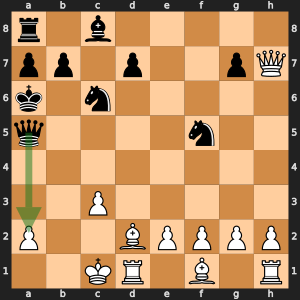

### [17/20] Arwanitakis, Michael vs Woeber, Friedrich — Black plays Qxa2 (variation)

> 20...Qxa2 when White should return material: 21. Qxf5 Qa3+ 22. Kc2 Qa4+ 23. Kb2 Qxd1 24. e4+ Kb6 25. Qd5 Qg4 ((else Be3+ wins the queen)) 26. Qd6 (and Be3+.); or 21. e4+ Kb6 22. Bf4 (should also win, giving the king room to escape the checks)

*Context: Both defending c3 and threatening e4+.*

#### Original extraction
1. Qxa2 defends the c3-square.
2. Qxa2 threatens e4+.

*Alternative* **d6**: 
  - Black might at least have tried d6.

*Variation*: `21. Qxf5 Qa3+ 22. Kc2 Qa4+ 23. Kb2 Qxd1 24. e4+ Kb6 25. Qd5 Qg4 26. Qd6 (and Be3+); or 21. e4+ Kb6 22. Bf4`

#### Reasoning filter decisions
✅ Qxa2 defends the c3-square.

✅ Qxa2 threatens e4+.

#### Alternative filter decisions
❌ [d6] Black might at least have tried d6. — *vague label — no concrete positional content*

#### Result
1. Qxa2 defends the c3-square.
2. Qxa2 threatens e4+.

**2 → 2 reasoning atoms (1 alt removed)**

---

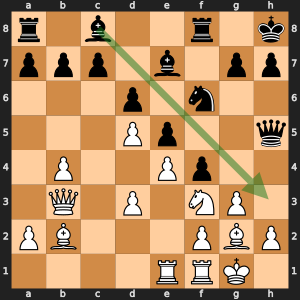

### [18/20] Miralles, Gilles vs Bologan, Viktor — Black plays Bh3 (mainline)

> All according to plan, ...Ng4 and ...fxg3 come next.

*Context: White wants to follow with d4 and open the centre, but this weakens f3.*

#### Original extraction
1. Bh3 prepares the maneuver Ng4.
2. Bh3 supports the upcoming ...fxg3.

*Variation*: `...Ng4 ...fxg3`

#### Reasoning filter decisions
🔄 Bh3 prepares the maneuver Ng4.

  → **After Bh3, Black prepares the maneuver ...Ng4.**

🔄 Bh3 supports the upcoming ...fxg3.

  → **After Bh3, Black supports the upcoming ...fxg3.**

#### Result
1. After Bh3, Black prepares the maneuver ...Ng4.
2. After Bh3, Black supports the upcoming ...fxg3.

**2 → 2 reasoning atoms (2 contextualized)**

---

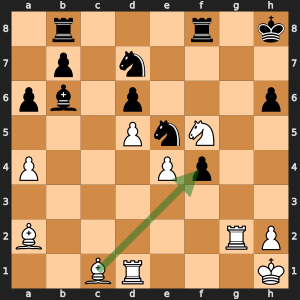

### [19/20] Sitnikov, Anton vs Aveskulov, Valeriy — White plays Bxf4 (variation)

> Black loses the pawn on h6, but moving the knight from e5 is the last thing he should do. Now White comes crashing through...

*Context: Suddenly the knight has access to the juicy f5 square.*

#### Original extraction
1. Bxf4 captures the pawn on f4.
2. Bxf4 prevents Black from moving the knight on e5, which would lose a key piece.

*Variation*: `White comes crashing through...`

#### Reasoning filter decisions
✅ Bxf4 captures the pawn on f4.

🔄 Bxf4 prevents Black from moving the knight on e5, which would lose a key piece.

  → **After Bxf4, Black cannot move the knight on e5 without losing a key piece.**

#### Result
1. Bxf4 captures the pawn on f4.
2. After Bxf4, Black cannot move the knight on e5 without losing a key piece.

**2 → 2 reasoning atoms (1 contextualized)**

---

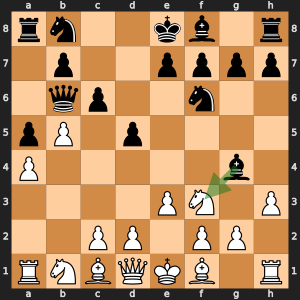

### [20/20] Ardaman, Miles vs Anka, Emil — Black plays Bxf3 (mainline)

> Taking over the centre without further ado. The bishops aren't really a consideration.

*Context: More of that clever-but-so-what stuff.*

#### Original extraction
1. Bxf3 takes control of the center.
2. The bishops are not considered a significant factor in this move.

#### Reasoning filter decisions
✅ Bxf3 takes control of the center.

❌ The bishops are not considered a significant factor in this move. — *vague label — no concrete positional content*

#### Result
1. Bxf3 takes control of the center.

**2 → 1 reasoning atoms (1 removed)**

---

In [7]:
for idx, (row, result, out_row) in enumerate(sample_results):
    board = chess.Board(row['fen'])
    move = chess.Move.from_uci(row['move_uci'])
    move_san = board.san(move)

    svg = chess.svg.board(
        board,
        arrows=[(move.from_square, move.to_square)],
        size=300,
    )
    display(SVG(svg))

    turn = 'White' if board.turn == chess.WHITE else 'Black'
    loc = 'mainline' if row.get('is_mainline') else 'variation'
    display(Markdown(
        f'### [{idx+1}/{len(sample_results)}] {row["game"]} \u2014 '
        f'{turn} plays {move_san} ({loc})'
    ))

    display(Markdown(f'> {row["annotation"]}'))

    if row.get('parent_comment'):
        display(Markdown(f'*Context: {row["parent_comment"]}*'))

    # --- Original reasoning + alternatives ---
    old_reasoning = row['extracted'].get('reasoning', [])
    old_alt = row['extracted'].get('alternative')
    old_var = row['extracted'].get('variation')

    orig_lines = []
    for i, a in enumerate(old_reasoning):
        orig_lines.append(f'{i+1}. {a}')
    orig_block = '\n'.join(orig_lines)

    if old_alt:
        alts = old_alt if isinstance(old_alt, list) else [old_alt]
        for a in alts:
            orig_block += f'\n\n*Alternative* **{a.get("move", "?")}**: '
            for r in a.get('reasoning', []):
                orig_block += f'\n  - {r}'

    if old_var:
        orig_block += f'\n\n*Variation*: `{old_var}`'

    display(Markdown(f'#### Original extraction\n{orig_block}'))

    # --- Filter decisions per reasoning atom ---
    atoms = result.get('atoms', [])
    if atoms:
        lines = []
        for a in atoms:
            action = a.get('action', 'keep')
            if action == 'keep':
                lines.append(f'\u2705 {a["text"]}')
            elif action == 'remove':
                reason = f' \u2014 *{a["reason"]}*' if a.get('reason') else ''
                lines.append(f'\u274c {a["text"]}{reason}')
            elif action == 'move_to_alternative':
                alt_move = a.get('move', '?')
                lines.append(f'\u27a1\ufe0f {a["text"]} \u2192 *alternative ({alt_move})*')
                if a.get('kept_brief'):
                    lines.append(f'  \u2192 kept brief: **{a["kept_brief"]}**')
            elif action == 'contextualize':
                lines.append(f'\U0001f504 {a["text"]}')
                if a.get('new_text'):
                    lines.append(f'  \u2192 **{a["new_text"]}**')
        display(Markdown('#### Reasoning filter decisions\n' + '\n\n'.join(lines)))

    # --- Filter decisions per alternative atom ---
    alt_atoms = result.get('alt_atoms', [])
    if alt_atoms:
        lines = []
        for a in alt_atoms:
            action = a.get('action', 'keep')
            prefix = f'[{a.get("alt_move", "?")}] '
            if action == 'keep':
                lines.append(f'\u2705 {prefix}{a["text"]}')
            elif action == 'remove':
                reason = f' \u2014 *{a["reason"]}*' if a.get('reason') else ''
                lines.append(f'\u274c {prefix}{a["text"]}{reason}')
            elif action == 'contextualize':
                lines.append(f'\U0001f504 {prefix}{a["text"]}')
                if a.get('new_text'):
                    lines.append(f'  \u2192 **{a["new_text"]}**')
        display(Markdown('#### Alternative filter decisions\n' + '\n\n'.join(lines)))

    # --- Resulting reasoning + alternatives ---
    new_reasoning = result['filtered_reasoning']
    new_alt = out_row['extracted'].get('alternative')

    result_block = ''
    if new_reasoning:
        result_block = '\n'.join(f'{i+1}. {a}' for i, a in enumerate(new_reasoning))
    else:
        result_block = '*No reasoning atoms remaining (will be EXCLUDED)*'

    if new_alt:
        alts = new_alt if isinstance(new_alt, list) else [new_alt]
        for a in alts:
            result_block += f'\n\n*Alternative* **{a.get("move", "?")}**:'
            for r in a.get('reasoning', []):
                result_block += f'\n  - {r}'

    display(Markdown(f'#### Result\n{result_block}'))

    # --- Summary line ---
    n_moved = len(result.get('new_alts_from_reasoning', []))
    n_ctx = sum(1 for a in atoms if a.get('action') == 'contextualize')
    n_removed = sum(1 for a in atoms if a.get('action') == 'remove')
    n_brief = sum(1 for a in atoms if a.get('kept_brief'))
    n_alt_removed = sum(1 for a in alt_atoms if a.get('action') == 'remove')
    n_alt_ctx = sum(1 for a in alt_atoms if a.get('action') == 'contextualize')

    summary = f'**{len(old_reasoning)} \u2192 {len(new_reasoning)} reasoning atoms'
    parts = []
    if n_removed > 0:
        parts.append(f'{n_removed} removed')
    if n_ctx > 0:
        parts.append(f'{n_ctx} contextualized')
    if n_moved > 0:
        parts.append(f'{n_moved} \u2192 alternative')
    if n_brief > 0:
        parts.append(f'{n_brief} kept brief')
    if n_alt_removed > 0:
        parts.append(f'{n_alt_removed} alt removed')
    if n_alt_ctx > 0:
        parts.append(f'{n_alt_ctx} alt contextualized')
    if parts:
        detail = ', '.join(parts)
        summary += f' ({detail})'
    summary += '**'
    display(Markdown(summary))

    display(Markdown('---'))

In [8]:
total_before = 0
total_after = 0
ctx_count = 0
moved_count = 0
removed_count = 0
alt_total = 0
alt_removed = 0
alt_ctx = 0

for row, result, out_row in sample_results:
    old = row['extracted'].get('reasoning', [])
    total_before += len(old)
    total_after += len(result['filtered_reasoning'])
    for a in result.get('atoms', []):
        action = a.get('action', 'keep')
        if action == 'remove':
            removed_count += 1
        elif action == 'contextualize':
            ctx_count += 1
        elif action == 'move_to_alternative':
            moved_count += 1
    for a in result.get('alt_atoms', []):
        alt_total += 1
        action = a.get('action', 'keep')
        if action == 'remove':
            alt_removed += 1
        elif action == 'contextualize':
            alt_ctx += 1

net = total_before - total_after
print(f'Sample reasoning: {total_before} atoms -> {total_after} ({net} net removed, {net/max(total_before,1)*100:.1f}%)')
print(f'  Contextualized: {ctx_count}')
print(f'  Moved to alternative: {moved_count}')
print(f'  Removed: {removed_count}')
print(f'\nSample alternatives: {alt_total} atoms classified')
print(f'  Removed: {alt_removed}')
print(f'  Contextualized: {alt_ctx}')

Sample reasoning: 31 atoms -> 29 (2 net removed, 6.5%)
  Contextualized: 9
  Moved to alternative: 0
  Removed: 2

Sample alternatives: 10 atoms classified
  Removed: 7
  Contextualized: 1


---
# Full run

In [9]:
OUTPUT_PATH = os.path.join(DIR, 'data', 'chesspublishinga_included_filtered.jsonl')
EXCLUDED_PATH = os.path.join(DIR, 'data', 'chesspublishinga_excluded_filtered.jsonl')

# Resume support
already_done = set()
for path in [OUTPUT_PATH, EXCLUDED_PATH]:
    if os.path.exists(path):
        with open(path) as f:
            for line in f:
                already_done.add(json.loads(line)['custom_id'])
if already_done:
    print(f'Resuming: {len(already_done)} already done')

todo = [r for r in all_rows if r['custom_id'] not in already_done]
print(f'To process: {len(todo)} / {len(all_rows)}')

CHUNK_SIZE = WORKERS * 4
n_included = 0
n_excluded = 0
n_atoms_before = 0
n_atoms_after = 0
n_ctx = 0
n_moved = 0
n_removed = 0
n_alt_total = 0
n_alt_removed = 0
n_alt_ctx = 0
t0 = time.time()

mode = 'a' if already_done else 'w'
sem = asyncio.Semaphore(WORKERS)

f_inc = open(OUTPUT_PATH, mode)
f_exc = open(EXCLUDED_PATH, mode)

try:
    for chunk_start in range(0, len(todo), CHUNK_SIZE):
        chunk = todo[chunk_start:chunk_start + CHUNK_SIZE]
        tasks = [filter_atoms(row, semaphore=sem) for row in chunk]
        results = await asyncio.gather(*tasks)

        for row, result in zip(chunk, results):
            old_n = len(row['extracted'].get('reasoning', []))
            new_n = len(result['filtered_reasoning'])
            n_atoms_before += old_n
            n_atoms_after += new_n

            for a in result.get('atoms', []):
                act = a.get('action', 'keep')
                if act == 'contextualize': n_ctx += 1
                elif act == 'move_to_alternative': n_moved += 1
                elif act == 'remove': n_removed += 1

            for a in result.get('alt_atoms', []):
                n_alt_total += 1
                act = a.get('action', 'keep')
                if act == 'remove': n_alt_removed += 1
                elif act == 'contextualize': n_alt_ctx += 1

            out_row = build_output_row(row, result)

            if result['filtered_reasoning']:
                f_inc.write(json.dumps(out_row) + '\n')
                n_included += 1
            else:
                out_row['exclude_reason'] = 'no reasoning atoms after filter'
                f_exc.write(json.dumps(out_row) + '\n')
                n_excluded += 1

        f_inc.flush()
        f_exc.flush()

        done = chunk_start + len(chunk)
        elapsed = time.time() - t0
        rate = done / elapsed
        print(f'  {done}/{len(todo)} done  '
              f'({n_included} inc / {n_excluded} exc)  '
              f'[{rate:.1f} req/s, {elapsed:.0f}s]')
finally:
    f_inc.close()
    f_exc.close()

elapsed = time.time() - t0
total = n_included + n_excluded
print(f'\n{"="*60}')
print(f'FILTER RESULTS ({total} positions in {elapsed:.0f}s)')
print(f'{"="*60}')
print(f'  Included:          {n_included:5d}')
print(f'  Excluded:          {n_excluded:5d}')
print(f'\n  Reasoning atoms:')
print(f'    Before:          {n_atoms_before:5d}')
print(f'    After:           {n_atoms_after:5d} ({n_atoms_before - n_atoms_after} net removed)')
print(f'    Contextualized:  {n_ctx:5d}')
print(f'    Moved to alt:    {n_moved:5d}')
print(f'    Removed:         {n_removed:5d}')
print(f'\n  Alternative atoms: {n_alt_total:5d} classified')
print(f'    Removed:         {n_alt_removed:5d}')
print(f'    Contextualized:  {n_alt_ctx:5d}')
print(f'\nWritten: {OUTPUT_PATH}')
print(f'Written: {EXCLUDED_PATH}')

Resuming: 421 already done
To process: 0 / 438

FILTER RESULTS (0 positions in 0s)
  Included:              0
  Excluded:              0

  Reasoning atoms:
    Before:              0
    After:               0 (0 net removed)
    Contextualized:      0
    Moved to alt:        0
    Removed:             0

  Alternative atoms:     0 classified
    Removed:             0
    Contextualized:      0

Written: /Users/ashwin/Documents/Princeton/chess/chess_annotation/evaluation/data/chesspublishing/data/chesspublishinga_included_filtered.jsonl
Written: /Users/ashwin/Documents/Princeton/chess/chess_annotation/evaluation/data/chesspublishing/data/chesspublishinga_excluded_filtered.jsonl
